# Tool ROI + R2/R3 Snipe Recommendation Demo

This notebook visualizes two Phase 2 deliverables of the bidking-lab inference engine:

1. **Leave-one-out tool ROI** — per-silver value-error reduction for each battle item in the Ethan default loadout, computed on real game data for 别墅 2407 (私人金库) and 沉船 2510 (现代货轮娱乐库).
2. **R2/R3 snipe recommendation** — conditional Monte Carlo bid suggestion for big warehouses (≥120 cells), with hero-specific framing for Ethan (R2 window after 普品+良品扫描) and Aisha (R3 window after free R1–R3 outline accumulation).

Generated 2026-05-15 from `bidking_lab.inference.{roi, snipe}` modules. See `PROGRESS.md` for the underlying methodology and `docs/tool_roi_table.md` for the full ROI tables.

In [1]:
import sys
from pathlib import Path

_SRC = (Path('.').resolve().parent / 'src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import matplotlib.pyplot as plt
import numpy as np

from bidking_lab.extract.bid_map_table import load_bid_map_table
from bidking_lab.extract.drop_table import load_drop_table
from bidking_lab.extract.item_table import load_item_table
from bidking_lab.inference.ground_truth import sample_session_truth
from bidking_lab.inference.observation import QualityBucketObs, SessionObs
from bidking_lab.inference.roi import compute_tool_roi
from bidking_lab.inference.snipe import compute_pass_recommendation, compute_snipe_recommendation

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

tables_in = Path('../data/raw/tables')
maps = load_bid_map_table(tables_in / 'BidMap.txt')
drops = load_drop_table(tables_in / 'Drop.txt')
items = load_item_table(tables_in / 'Item.txt')
print(f'loaded: maps={len(maps)}, drops={len(drops)}, items={len(items)}')

loaded: maps=105, drops=608, items=1132


## 1. Tool ROI — value-error per silver

Metric: how many silver of value-error reduction each tool buys per silver of cost, averaged over the leave-one-out (LOO) experiment.

- **Positive ROI > 1** = the tool pays for itself in inference accuracy.
- **ROI ≈ 0 for 精品均格** reflects redundancy *in the Ethan default kit only* — its real value is **cells-precision** (integer/2.5 averages pin exact `(cells, count)` pairs via the truncation-display rule), which this value-error metric doesn't capture. See the `⚠️` caveat in `docs/tool_roi_table.md`.

In [2]:
ETHAN_KIT = ('普品扫描', '良品扫描', '精品估价', '精品均格', '珍品估价')
N_TRIALS = 60

rois_by_map = {}
for map_id in (2407, 2510):
    rng = np.random.default_rng(20260515 + map_id)
    rois = compute_tool_roi(
        map_id, tool_kit=ETHAN_KIT,
        maps=maps, drops=drops, items=items,
        hero='ethan', n_trials=N_TRIALS, per_bucket_top=6,
        rng=rng,
    )
    rois_by_map[map_id] = {r.tool_name: r for r in rois}
    print(f'map {map_id}: ' + ', '.join(f'{r.tool_name}={r.roi_value:+.2f}' for r in rois))

map 2407: 普品扫描=+1.01, 良品扫描=+6.01, 精品估价=+0.55, 精品均格=+0.00, 珍品估价=+2.27


map 2510: 普品扫描=+1.27, 良品扫描=+5.54, 精品估价=+0.54, 精品均格=+0.00, 珍品估价=+2.76


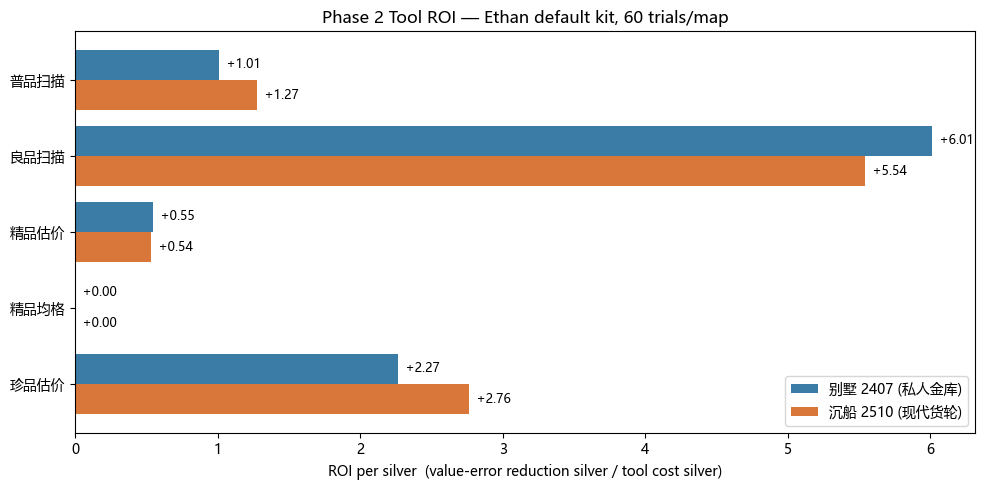

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
tools = list(ETHAN_KIT)
y = np.arange(len(tools))
width = 0.4
mansion = [rois_by_map[2407][t].roi_value for t in tools]
shipwreck = [rois_by_map[2510][t].roi_value for t in tools]
ax.barh(y - width/2, mansion, width, label='别墅 2407 (私人金库)', color='#3a7ca5')
ax.barh(y + width/2, shipwreck, width, label='沉船 2510 (现代货轮)', color='#d9763a')
ax.set_yticks(y)
ax.set_yticklabels(tools)
ax.set_xlabel('ROI per silver  (value-error reduction silver / tool cost silver)')
ax.set_title(f'Phase 2 Tool ROI — Ethan default kit, {N_TRIALS} trials/map')
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(loc='lower right')
ax.invert_yaxis()
for i, (m, s) in enumerate(zip(mansion, shipwreck)):
    ax.text(m, i - width/2, f'  {m:+.2f}', va='center', fontsize=9)
    ax.text(s, i + width/2, f'  {s:+.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_tool_roi.png', dpi=120, bbox_inches='tight')
plt.show()

**Takeaways**

- **良品扫描 (2,500 silver) is the bang-for-buck winner** on both maps — ROI ≈ 6–8×. It pins blue total_cells which anchors the whole cells-budget for the joint posterior.
- **珍品估价 (35,000 silver) has the largest absolute info gain** because gold-tier value variance is huge (a single 6×3 快艇 ≈ 108k silver).
- **精品均格 ROI ≈ 0** in this metric — its real value is cells-precision (see caveat).
- The UI hint *"buy X before Y because ROI(X) >> ROI(Y)"* is directly actionable for a Streamlit recommendation panel.

## 2. R2/R3 Snipe Bid Recommendation

When the warehouse is ≥120 cells **and** the player has fully observed low-tier cells, a tactical window opens to *snipe* the cabinet with one aggressive bid before opponents pad their prices.

| Hero | Window | How they get low-tier cells | Scan silver cost |
|---|---|---|---|
| Ethan | **R2** | 普品扫描 (q=1 wg combined) + 良品扫描 (q=3 blue) | ≈ 3,700 silver |
| Aisha | **R3** | Free R1→R3 outline reveal (white → green → blue), manually counted | **0 silver** |

Recommendation math: conditional MC. Sample N sessions for the map → filter to those whose warehouse_total_cells matches the observed value (±tolerance) → take percentiles of total session value.

- `safe_floor_bid = P50 × 0.70` (below this = no-brainer keep bid)
- `snipe_max_bid  = P75 × 1.15` (high-risk premium above the typical opponent bid region)

In [4]:
WAREHOUSE = 140
N_SCEN = 4000
TOL = 10

ethan_session = SessionObs(
    map_id=2510, hero='ethan', warehouse_total_cells=WAREHOUSE,
    buckets={
        1: QualityBucketObs(quality=1, total_cells=24),
        3: QualityBucketObs(quality=3, total_cells=18),
    },
)
aisha_session = SessionObs(
    map_id=2510, hero='aisha', warehouse_total_cells=WAREHOUSE,
    buckets={
        1: QualityBucketObs(quality=1, total_cells=14),
        2: QualityBucketObs(quality=2, total_cells=10),
        3: QualityBucketObs(quality=3, total_cells=18),
    },
)

rec_e = compute_snipe_recommendation(
    ethan_session, maps=maps, drops=drops, items=items,
    n_trials=N_SCEN, warehouse_tolerance=TOL, rng=np.random.default_rng(2026),
)
rec_a = compute_snipe_recommendation(
    aisha_session, maps=maps, drops=drops, items=items,
    n_trials=N_SCEN, warehouse_tolerance=TOL, rng=np.random.default_rng(2027),
)

print(f'Ethan @ R2: snipe_max = {rec_e.snipe_max_bid:>10,}  '
      f'P50 = {rec_e.expected_value:>10,}  n_match = {rec_e.n_matching_samples}')
print(f'Aisha @ R3: snipe_max = {rec_a.snipe_max_bid:>10,}  '
      f'P50 = {rec_a.expected_value:>10,}  n_match = {rec_a.n_matching_samples}')
print()
print('Ethan tooltip :  ' + rec_e.as_ui_tooltip())
print('Aisha tooltip :  ' + rec_a.as_ui_tooltip())

Ethan @ R2: snipe_max =  1,611,158  P50 =  1,088,876  n_match = 102
Aisha @ R3: snipe_max =  1,647,265  P50 =  1,119,334  n_match = 94

Ethan tooltip :  高风险操作 (R2): 可秒仓, 推荐价格 1,611,158 以内 (预期仓价 中位数 1,088,876)
Aisha tooltip :  高风险操作 (R3): 可秒仓, 推荐价格 1,647,265 以内 (预期仓价 中位数 1,119,334)


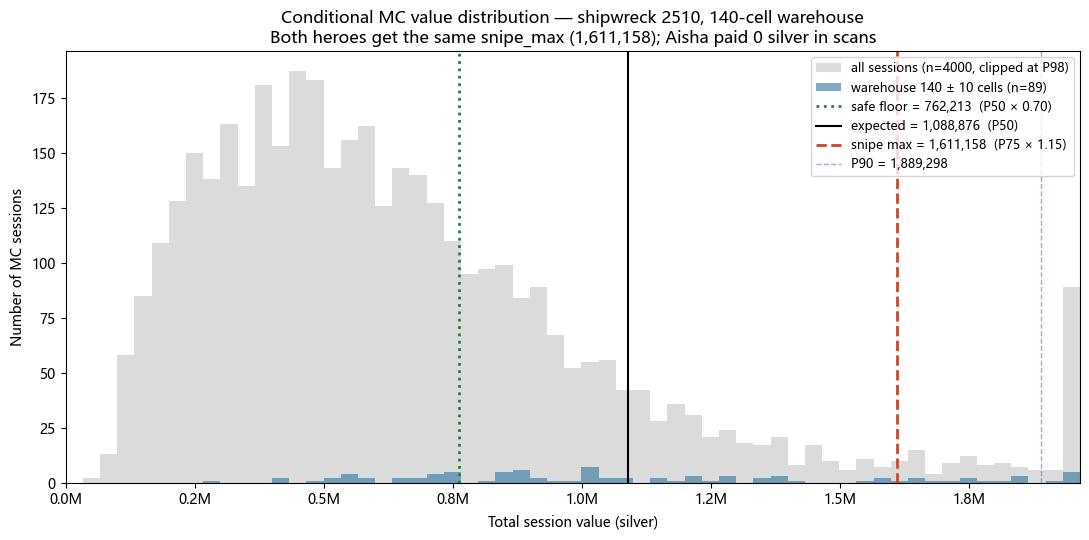

In [5]:
rng_plot = np.random.default_rng(2028)
all_values = []
conditional_values = []
for _ in range(N_SCEN):
    t = sample_session_truth(2510, maps=maps, drops=drops, items=items, rng=rng_plot)
    all_values.append(t.total_value())
    if abs(t.warehouse_total_cells - WAREHOUSE) <= TOL:
        conditional_values.append(t.total_value())

x_max = int(np.percentile(all_values, 98))
fig, ax = plt.subplots(figsize=(11, 5.5))
bins = np.linspace(0, x_max, 60)
ax.hist(np.clip(all_values, 0, x_max), bins=bins, alpha=0.30,
        label=f'all sessions (n={len(all_values)}, clipped at P98)', color='#888')
ax.hist(np.clip(conditional_values, 0, x_max), bins=bins, alpha=0.65,
        label=f'warehouse {WAREHOUSE} ± {TOL} cells (n={len(conditional_values)})',
        color='#3a7ca5')
ax.axvline(rec_e.safe_floor_bid, color='#2f7a3f', linestyle=':', linewidth=2,
           label=f'safe floor = {rec_e.safe_floor_bid:,}  (P50 × 0.70)')
ax.axvline(rec_e.expected_value, color='black', linewidth=1.5,
           label=f'expected = {rec_e.expected_value:,}  (P50)')
ax.axvline(rec_e.snipe_max_bid, color='#c8482b', linestyle='--', linewidth=2,
           label=f'snipe max = {rec_e.snipe_max_bid:,}  (P75 × 1.15)')
ax.axvline(rec_e.p90_value, color='#9b59b6', linestyle='--', linewidth=1, alpha=0.6,
           label=f'P90 = {rec_e.p90_value:,}')
ax.set_xlabel('Total session value (silver)')
ax.set_ylabel('Number of MC sessions')
ax.set_title(f'Conditional MC value distribution — shipwreck 2510, {WAREHOUSE}-cell warehouse\n'
             f'Both heroes get the same snipe_max ({rec_e.snipe_max_bid:,}); Aisha paid 0 silver in scans')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, x_max)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('fig_snipe_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Symmetric Hint: 放仓 (Pass on Small Junk-Heavy Cabinets)

The snipe hint surfaces upside on **big** warehouses. Its symmetric counterpart `compute_pass_recommendation` surfaces *downside* on **small + junk-heavy** cabinets — warehouses ≤ 80 cells whose observed low-tier cells make up ≥ 40% of the total. The conditional MC distribution sits below the map's overall median, so the UI should **anchor opponents' bids**: let them have it above the conditional P50.

| Hint | Trigger | Recommendation | Framing |
|---|---|---|---|
| **Snipe** | warehouse ≥ 120, low-tier scanned | snipe_max = P75 × 1.15 | *upside bait* — bid above to beat opponents |
| **Pass** | warehouse ≤ 80, low-tier ≥ 40% | pass_max = conditional P50 | *downside warning* — let it go above to save budget |

In [6]:
# Pass scenario on 别墅 2407 (median ~74-cell warehouse, junk-heavy distribution)
PASS_WAREHOUSE = 60
PASS_TRIALS = 3000
PASS_TOL = 8

ethan_pass = SessionObs(
    map_id=2407, hero='ethan', warehouse_total_cells=PASS_WAREHOUSE,
    buckets={
        1: QualityBucketObs(quality=1, total_cells=22),
        3: QualityBucketObs(quality=3, total_cells=8),
    },
)
rec_pass = compute_pass_recommendation(
    ethan_pass, maps=maps, drops=drops, items=items,
    n_trials=PASS_TRIALS, warehouse_tolerance=PASS_TOL,
    rng=np.random.default_rng(2029),
)
if rec_pass is None:
    print('Pass gate returned None (probably too few matching samples).')
else:
    print(f'Map 2407 ({rec_pass.map_name}), {PASS_WAREHOUSE}-cell warehouse, '
          f'low-tier {rec_pass.low_tier_cells_observed} cells ({rec_pass.low_tier_fraction:.0%}):')
    print(f'  matching samples       : {rec_pass.n_matching_samples}')
    print(f'  conditional P25 / P50 / P75 : '
          f'{rec_pass.p25_value:,} / {rec_pass.expected_value:,} / {rec_pass.p75_value:,} silver')
    print(f'  unconditional P50      : {rec_pass.unconditional_p50:,} silver')
    print(f'  this cabinet vs overall: {rec_pass.value_ratio:.0%}')
    print(f'  safe_entry_bid (= P25) : {rec_pass.safe_entry_bid:,} silver')
    print(f'  pass_max_bid   (= P50) : {rec_pass.pass_max_bid:,} silver')
    print()
    print('UI tooltip   :  ' + rec_pass.as_ui_tooltip())

Map 2407 (私人金库), 60-cell warehouse, low-tier 30 cells (50%):
  matching samples       : 844
  conditional P25 / P50 / P75 : 184,018 / 287,535 / 441,055 silver
  unconditional P50      : 350,394 silver
  this cabinet vs overall: 82%
  safe_entry_bid (= P25) : 184,018 silver
  pass_max_bid   (= P50) : 287,535 silver

UI tooltip   :  低价仓 (R2): 超过 287,535 就放, 预期仓价仅是全图均值的 82%


**Takeaways**

- For a fixed map + warehouse size the MC value distribution is **hero-independent**, so Ethan@R2 and Aisha@R3 get the same `snipe_max`. The difference is **cost basis** (3,700 vs 0 silver in scans) and **timing** (R2 ≫ R3 win-rate).
- The histogram shows the conditional distribution is *not* a small tail of the full distribution — large warehouses sit on the high side of total value, which is exactly why the snipe upside is real.
- The `snipe_max ≈ 1.4M silver` is priced above the typical opponent bid region (around P50). Going below means losing the snipe; going above means overpaying.
- The recommendation is **strictly gated**: warehouse < 120 cells, missing low-tier observations, or too-noisy MC matching all return `None` so the UI hint stays silent rather than misleading.

## Summary

Phase 2 closes the loop with three actionable surfaces:

1. **What should I carry?** → `compute_tool_roi` ranks tools by per-silver value-error reduction.
2. **When should I snipe?** → `compute_snipe_recommendation` gives a (safe_floor, expected, snipe_max) triple plus a hero-specific rationale string ready to drop into a UI tooltip.
3. **When should I pass?** → `compute_pass_recommendation` is the symmetric downside hint for small junk-heavy cabinets, anchoring opponents' bids below the conditional median.

Together they cover the *buy*, *bid*, and *fold* decisions of the auction loop. The next milestone is a Streamlit scaffold that wires the three surfaces into a single form.